# CBLV Encoding Demo

This notebook demonstrates the CBLV (Compact Bijective Ladderized Vector) encoding for phylogenetic trees.

In [8]:
import dendropy as dp
import numpy as np
import random
from dendropy.simulate import treesim

random.seed(42)
np.random.seed(42)

# ============================================================
# Example 1: Simple tree where C tips are CLUSTERED
# This demonstrates the stem distance correction
# ============================================================

# Tree structure:
#              root
#            /      \
#     stem=1.0      (A,B clade)
#          |           |
#      MRCA of C    ...A,B tips...
#        /   \
#      C1    C2 (at distance 2 from root)

# Create a tree where C tips are in one subtree (clustered)
newick_clustered = """
(
  ((C1:0.5,C2:0.7):0.5,(C3:0.6,C4:0.8):0.4):1.0,
  ((A1:0.9,A2:0.8):0.6,(B1:1.0,B2:0.7):0.5):0.8
):0.0;
"""

phy = dp.Tree.get(data=newick_clustered, schema='newick')
phy.is_rooted = True
phy.calc_node_root_distances()

print("=== EXAMPLE TREE (C tips clustered in one subtree) ===")
print("Tree structure:")
print("            root (0.0)")
print("           /         \\")
print("    stem=1.0         stem=0.8")
print("         |              |")
print("     MRCA(C)      MRCA(A,B)")
print("      /    \\        /    \\")
print("   (C1,C2)(C3,C4) (A1,A2)(B1,B2)")

print(f"\nAll tip root distances:")
for nd in phy.leaf_node_iter():
    loc = nd.taxon.label[0]
    print(f"  {nd.taxon.label}: {nd.root_distance:.2f} [{loc}]")

# Find MRCA of C tips
tips_C_taxa = [nd.taxon for nd in phy.leaf_node_iter() if nd.taxon.label.startswith('C')]
mrca_C = phy.mrca(taxa=tips_C_taxa)
stem_distance = mrca_C.root_distance

print(f"\n→ MRCA of C tips is at root_distance: {stem_distance:.2f}")
print(f"→ This is the STEM that will be ADDED to subtree distances")

# Add location annotations
for leaf in phy.leaf_node_iter():
    location = leaf.taxon.label[0]
    leaf.annotations.add_new('location', location)

print(f"\nTips by location:")
for loc in ['A', 'B', 'C']:
    tips_in_loc = [nd.taxon.label for nd in phy.leaf_node_iter() 
                   if nd.taxon.label.startswith(loc)]
    print(f"  Location {loc}: {tips_in_loc}")

=== EXAMPLE TREE (C tips clustered in one subtree) ===
Tree structure:
            root (0.0)
           /         \
    stem=1.0         stem=0.8
         |              |
     MRCA(C)      MRCA(A,B)
      /    \        /    \
   (C1,C2)(C3,C4) (A1,A2)(B1,B2)

All tip root distances:
  C1: 2.00 [C]
  C2: 2.20 [C]
  C3: 2.00 [C]
  C4: 2.20 [C]
  A1: 2.30 [A]
  A2: 2.20 [A]
  B1: 2.30 [B]
  B2: 2.00 [B]

→ MRCA of C tips is at root_distance: 1.00
→ This is the STEM that will be ADDED to subtree distances

Tips by location:
  Location A: ['A1', 'A2']
  Location B: ['B1', 'B2']
  Location C: ['C1', 'C2', 'C3', 'C4']


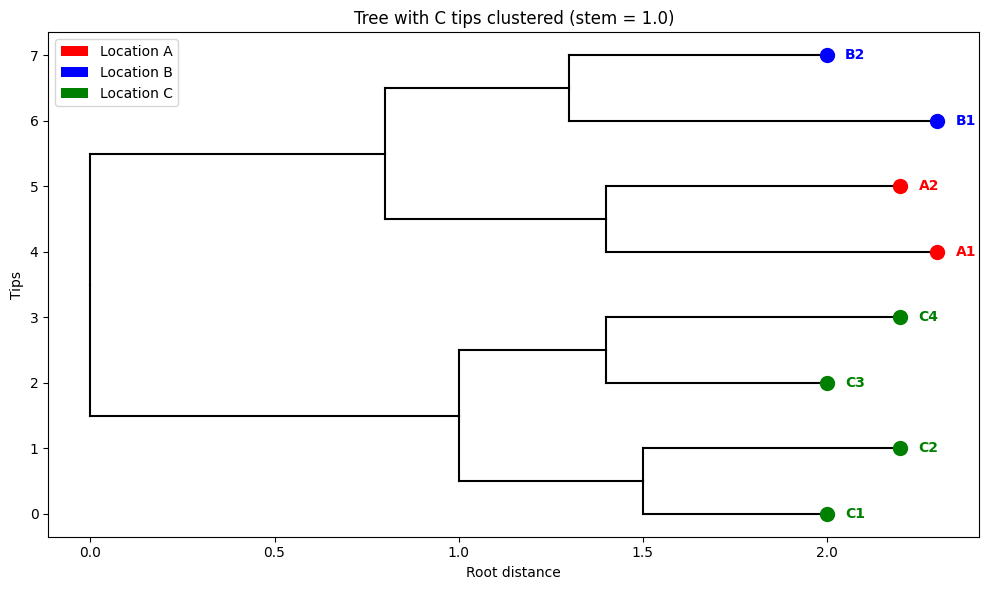

Tree height: 2.30
MRCA of C tips at distance 1.00 from root


In [9]:
# Visualize the tree with tips colored by location

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Define colors for each location
location_colors = {'A': 'red', 'B': 'blue', 'C': 'green'}

def plot_tree(phy, ax=None, title="Phylogenetic Tree"):
    """Simple tree visualization."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    phy.calc_node_root_distances()
    
    # Assign y-coordinates to leaves (evenly spaced)
    leaves = list(phy.leaf_node_iter())
    for i, leaf in enumerate(leaves):
        leaf.y_coord = i
    
    # Assign y-coordinates to internal nodes (midpoint of children)
    for nd in phy.postorder_node_iter():
        if not nd.is_leaf():
            children = nd.child_nodes()
            nd.y_coord = sum(c.y_coord for c in children) / len(children)
    
    # Draw edges
    for nd in phy.preorder_node_iter():
        if nd.parent_node:
            ax.plot([nd.parent_node.root_distance, nd.root_distance], 
                   [nd.y_coord, nd.y_coord], 'k-', linewidth=1.5)
            ax.plot([nd.parent_node.root_distance, nd.parent_node.root_distance],
                   [nd.parent_node.y_coord, nd.y_coord], 'k-', linewidth=1.5)
    
    # Draw leaf labels with colors
    for leaf in leaves:
        location = leaf.taxon.label[0]  # First character: A, B, or C
        color = location_colors.get(location, 'black')
        ax.plot(leaf.root_distance, leaf.y_coord, 'o', color=color, markersize=10)
        ax.text(leaf.root_distance + 0.05, leaf.y_coord, leaf.taxon.label, 
               fontsize=10, va='center', color=color, fontweight='bold')
    
    # Add legend
    legend_elements = [Patch(facecolor=c, label=f'Location {loc}') 
                      for loc, c in location_colors.items()]
    ax.legend(handles=legend_elements, loc='upper left')
    
    ax.set_xlabel('Root distance')
    ax.set_ylabel('Tips')
    ax.set_title(title)
    
    return ax

# Plot the tree
fig, ax = plt.subplots(figsize=(10, 6))
plot_tree(phy, ax, title="Tree with C tips clustered (stem = 1.0)")
plt.tight_layout()
plt.show()

print(f"Tree height: {max(nd.root_distance for nd in phy.leaf_node_iter()):.2f}")
print(f"MRCA of C tips at distance {stem_distance:.2f} from root")

In [10]:
# Extract subtree containing only Location C tips
# IMPORTANT: Preserve root distances relative to the ORIGINAL tree root

# Step 1: Find the MRCA of C tips in the ORIGINAL tree (before any modification)
tips_C_taxa = [nd.taxon for nd in phy.leaf_node_iter() if nd.taxon.label.startswith('C')]
tips_C_labels = [t.label for t in tips_C_taxa]

mrca_C = phy.mrca(taxa=tips_C_taxa)
stem_distance = mrca_C.root_distance  # Distance from original root to MRCA of C tips

print(f"Original tree: {len(phy.leaf_nodes())} tips")
print(f"MRCA of C tips is at root_distance: {stem_distance:.2f}")
print(f"→ This STEM distance will be ADDED to preserve original root distances")

# Step 2: Clone and prune non-C tips
subtree_C = phy.clone(depth=1)
taxa_to_remove = [nd.taxon for nd in subtree_C.leaf_node_iter() 
                  if not nd.taxon.label.startswith('C')]

print(f"\nRemoving {len(taxa_to_remove)} non-C tips")
subtree_C.prune_taxa(taxa_to_remove)
subtree_C.suppress_unifurcations()  # Make binary for CBLV encoding
subtree_C.calc_node_root_distances()

# Step 3: Store the stem distance for later use in CBLV encoding
subtree_C.stem_distance = stem_distance

print(f"\nSubtree statistics:")
print(f"  Number of tips: {len(subtree_C.leaf_nodes())}")
print(f"  Stem distance: {stem_distance:.2f}")

# Step 4: Show the PROBLEM and SOLUTION
print(f"\n{'='*60}")
print(f"PROBLEM: Without stem correction, subtree loses original distances")
print(f"{'='*60}")
print(f"{'Tip':<10} {'Original':<12} {'Subtree':<12} {'ERROR':<12}")
print("-" * 48)
for label in tips_C_labels:
    orig_leaf = [nd for nd in phy.leaf_node_iter() if nd.taxon.label == label][0]
    sub_leaf = [nd for nd in subtree_C.leaf_node_iter() if nd.taxon.label == label][0]
    error = orig_leaf.root_distance - sub_leaf.root_distance
    print(f"{label:<10} {orig_leaf.root_distance:<12.2f} {sub_leaf.root_distance:<12.2f} -{error:.2f}")

print(f"\n{'='*60}")
print(f"SOLUTION: Add stem distance ({stem_distance:.2f}) to restore original distances")
print(f"{'='*60}")
print(f"{'Tip':<10} {'Subtree':<10} {'+Stem':<10} {'=Corrected':<12} {'Original':<10} {'Match'}")
print("-" * 65)
for label in tips_C_labels:
    orig_leaf = [nd for nd in phy.leaf_node_iter() if nd.taxon.label == label][0]
    sub_leaf = [nd for nd in subtree_C.leaf_node_iter() if nd.taxon.label == label][0]
    corrected = sub_leaf.root_distance + stem_distance
    match = "✓" if abs(orig_leaf.root_distance - corrected) < 0.01 else "✗"
    print(f"{label:<10} {sub_leaf.root_distance:<10.2f} {stem_distance:<10.2f} {corrected:<12.2f} {orig_leaf.root_distance:<10.2f} {match}")

Original tree: 8 tips
MRCA of C tips is at root_distance: 1.00
→ This STEM distance will be ADDED to preserve original root distances

Removing 4 non-C tips

Subtree statistics:
  Number of tips: 4
  Stem distance: 1.00

PROBLEM: Without stem correction, subtree loses original distances
Tip        Original     Subtree      ERROR       
------------------------------------------------
C1         2.00         1.00         -1.00
C2         2.20         1.20         -1.00
C3         2.00         1.00         -1.00
C4         2.20         1.20         -1.00

SOLUTION: Add stem distance (1.00) to restore original distances
Tip        Subtree    +Stem      =Corrected   Original   Match
-----------------------------------------------------------------
C1         1.00       1.00       2.00         2.00       ✓
C2         1.20       1.00       2.20         2.20       ✓
C3         1.00       1.00       2.00         2.00       ✓
C4         1.20       1.00       2.20         2.20       ✓


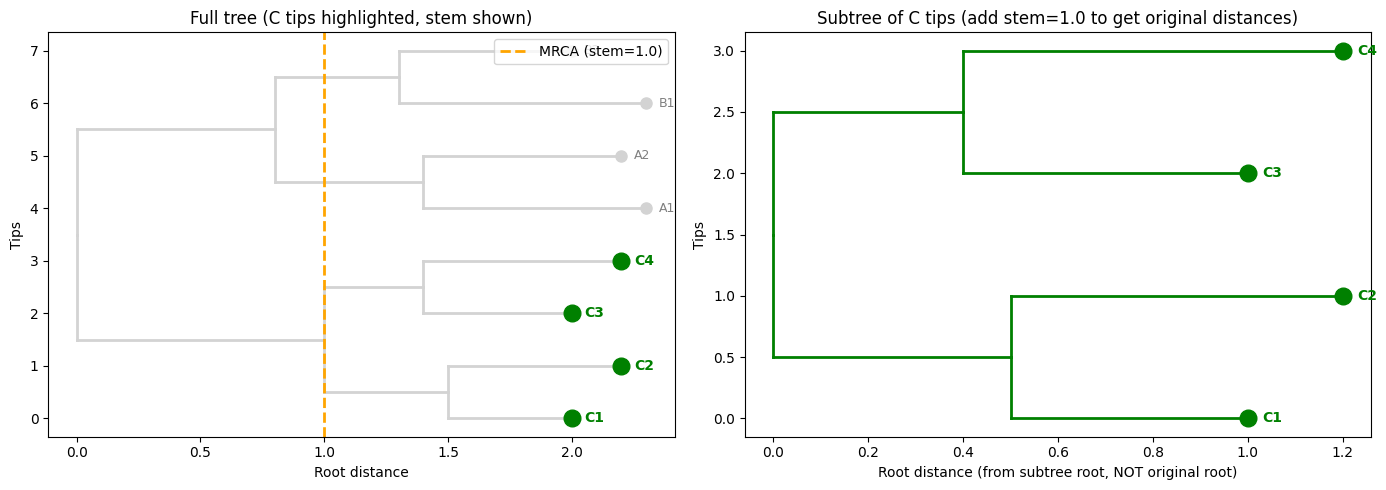


Note: Subtree distances start at 0 (subtree root = MRCA of C tips)
To get original root distances, add stem_distance = 1.00


In [11]:
# Visualize: Full tree vs Location C subtree

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Full tree with C tips highlighted
ax1 = axes[0]

leaves = list(phy.leaf_node_iter())
for i, leaf in enumerate(leaves):
    leaf.y_coord = i

for nd in phy.postorder_node_iter():
    if not nd.is_leaf():
        children = nd.child_nodes()
        nd.y_coord = sum(c.y_coord for c in children) / len(children)

for nd in phy.preorder_node_iter():
    if nd.parent_node:
        ax1.plot([nd.parent_node.root_distance, nd.root_distance], 
               [nd.y_coord, nd.y_coord], 'lightgray', linewidth=2)
        ax1.plot([nd.parent_node.root_distance, nd.parent_node.root_distance],
               [nd.parent_node.y_coord, nd.y_coord], 'lightgray', linewidth=2)

for leaf in leaves:
    location = leaf.taxon.label[0]
    if location == 'C':
        ax1.plot(leaf.root_distance, leaf.y_coord, 'o', color='green', markersize=12)
        ax1.text(leaf.root_distance + 0.05, leaf.y_coord, leaf.taxon.label, 
               fontsize=10, va='center', color='green', fontweight='bold')
    else:
        ax1.plot(leaf.root_distance, leaf.y_coord, 'o', color='lightgray', markersize=8)
        ax1.text(leaf.root_distance + 0.05, leaf.y_coord, leaf.taxon.label, 
               fontsize=9, va='center', color='gray')

# Draw stem indicator
ax1.axvline(x=stem_distance, color='orange', linestyle='--', linewidth=2, label=f'MRCA (stem={stem_distance:.1f})')
ax1.legend(loc='upper right')

ax1.set_xlabel('Root distance')
ax1.set_ylabel('Tips')
ax1.set_title('Full tree (C tips highlighted, stem shown)')

# Right: Subtree of C tips only
ax2 = axes[1]

subtree_leaves = list(subtree_C.leaf_node_iter())
for i, leaf in enumerate(subtree_leaves):
    leaf.y_coord = i

for nd in subtree_C.postorder_node_iter():
    if not nd.is_leaf():
        children = nd.child_nodes()
        nd.y_coord = sum(c.y_coord for c in children) / len(children)

for nd in subtree_C.preorder_node_iter():
    if nd.parent_node:
        ax2.plot([nd.parent_node.root_distance, nd.root_distance], 
               [nd.y_coord, nd.y_coord], 'green', linewidth=2)
        ax2.plot([nd.parent_node.root_distance, nd.parent_node.root_distance],
               [nd.parent_node.y_coord, nd.y_coord], 'green', linewidth=2)

for leaf in subtree_leaves:
    ax2.plot(leaf.root_distance, leaf.y_coord, 'o', color='green', markersize=12)
    ax2.text(leaf.root_distance + 0.03, leaf.y_coord, leaf.taxon.label, 
           fontsize=10, va='center', color='green', fontweight='bold')

ax2.set_xlabel('Root distance (from subtree root, NOT original root)')
ax2.set_ylabel('Tips')
ax2.set_title(f'Subtree of C tips (add stem={stem_distance:.1f} to get original distances)')

plt.tight_layout()
plt.show()

print(f"\nNote: Subtree distances start at 0 (subtree root = MRCA of C tips)")
print(f"To get original root distances, add stem_distance = {stem_distance:.2f}")

In [12]:
# Compute CBLV encoding for the Location C subtree
# with root distances adjusted to original tree root

def encode_cblv(phy, tree_width, tree_encode_type='height_brlen', rescale=True, 
                stem_distance=0, tree_height=None):
    """
    Encode Compact Bijective Ladderized Vector (CBLV) array.
    
    Args:
        phy: The subtree to encode
        tree_width: Number of tips (rows in output matrix)
        tree_encode_type: 'height_only' (2 cols) or 'height_brlen' (4 cols)
        rescale: Whether to normalize values
        stem_distance: Distance from original root to subtree root (MRCA).
                       Added to Col0[0,0] and Col1 to preserve true root distances.
        tree_height: Height of the ORIGINAL tree for rescaling (REQUIRED if rescale=True).
    """
    if tree_encode_type == 'height_only':
        num_tree_col = 2
    elif tree_encode_type == 'height_brlen':
        num_tree_col = 4

    phy.calc_node_root_distances(return_leaf_distances_only=False)
    heights = np.zeros((tree_width, num_tree_col))
    height_idx = 0

    # =========================================
    # Step 1: Postorder traversal - Ladderize
    # =========================================
    for nd in phy.postorder_node_iter():
        if nd.is_leaf():
            nd.max_root_distance = nd.root_distance
        else:
            children = nd.child_nodes()
            ch_max_root_distance = [ch.max_root_distance for ch in children]
            ch_max_root_distance_rank = np.argsort(ch_max_root_distance)[::-1]
            children_reordered = [children[i] for i in ch_max_root_distance_rank]
            nd.max_root_distance = max(ch_max_root_distance)
            nd.set_children(children_reordered)

    # =========================================
    # Step 2: Inorder traversal - Fill matrix
    # =========================================
    last_int_node = phy.seed_node
    if last_int_node.edge.length is None:
        last_int_node.edge.length = 0

    for nd in phy.inorder_node_iter():
        if height_idx >= tree_width:
            break
        if nd.is_leaf():
            # Col0: distance from leaf to last internal node
            if height_idx == 0:
                # First leaf: add stem to extend branch to TRUE root
                heights[height_idx, 0] = nd.root_distance - last_int_node.root_distance + stem_distance
            else:
                heights[height_idx, 0] = nd.root_distance - last_int_node.root_distance
            # Col2: leaf branch length
            if tree_encode_type == 'height_brlen':
                heights[height_idx, 2] = nd.edge.length if nd.edge.length else 0
        else:
            if height_idx + 1 < tree_width:
                # Col1: internal node distance from TRUE root
                heights[height_idx + 1, 1] = nd.root_distance + stem_distance
                # Col3: internal branch length
                if tree_encode_type == 'height_brlen':
                    heights[height_idx + 1, 3] = nd.edge.length if nd.edge.length else 0
            last_int_node = nd
            height_idx += 1

    # =========================================
    # Step 3: Rescale using ORIGINAL tree height
    # =========================================
    if rescale:
        if tree_height is None:
            raise ValueError("tree_height is required when rescale=True. Use original tree height.")
        heights = heights / tree_height

    return heights


# =========================================
# Demo
# =========================================

stem_dist = getattr(subtree_C, 'stem_distance', 0)
num_tips_C = len(subtree_C.leaf_nodes())

# Get original tree height
original_tree_height = max(nd.root_distance for nd in phy.leaf_node_iter())

print(f"CBLV encoding for Location C subtree")
print(f"  Stem distance: {stem_dist:.2f}")
print(f"  Original tree height: {original_tree_height:.2f}")
print(f"  Output shape: ({num_tips_C}, 4)")

# Compute CBLV with stem correction and original tree height rescaling
cblv = encode_cblv(
    subtree_C, 
    tree_width=num_tips_C, 
    rescale=True, 
    stem_distance=stem_dist,
    tree_height=original_tree_height
)

print(f"\n{'='*50}")
print(f"CBLV Matrix (rescaled by tree height {original_tree_height:.2f})")
print(f"{'='*50}")
print(f"{'Row':<5} {'Col0':<10} {'Col1':<10} {'Col2':<10} {'Col3':<10}")
print("-" * 45)
for i in range(num_tips_C):
    print(f"{i:<5} {cblv[i,0]:<10.3f} {cblv[i,1]:<10.3f} {cblv[i,2]:<10.3f} {cblv[i,3]:<10.3f}")

CBLV encoding for Location C subtree
  Stem distance: 1.00
  Original tree height: 2.30
  Output shape: (4, 4)

CBLV Matrix (rescaled by tree height 2.30)
Row   Col0       Col1       Col2       Col3      
---------------------------------------------
0     0.957      0.000      0.348      0.000     
1     0.261      0.609      0.261      0.174     
2     0.522      0.435      0.304      0.435     
3     0.217      0.652      0.217      0.217     


In [13]:
# =========================================
# Real Data: Load BEAST2 tree file
# =========================================

# Load tree file (NEXUS format with multiple trees)
tree_file = "/Users/lukelyu/Desktop/epidata/40_5_MM0.003/0_beast2.trees"

# Read all trees from the file
# Use suppress_leaf_node_taxa=True to handle duplicate taxon labels
tree_list = dp.TreeList.get(
    path=tree_file, 
    schema='nexus',
    suppress_internal_node_taxa=True,
    suppress_leaf_node_taxa=True  # Handle duplicate labels
)
print(f"Loaded {len(tree_list)} trees from file")

# Get STATE_0 (first tree)
phy_real = tree_list[0]
phy_real.is_rooted = True

# Count tips and internal nodes before collapsing
n_tips_before = len(phy_real.leaf_nodes())
n_internal_before = len([n for n in phy_real.postorder_node_iter() if not n.is_leaf()])

print(f"\nBefore collapsing unifurcations:")
print(f"  Tips: {n_tips_before}")
print(f"  Internal nodes: {n_internal_before}")

# Check for unifurcations (nodes with only 1 child)
unifurcations = [n for n in phy_real.postorder_node_iter() 
                 if not n.is_leaf() and len(n.child_nodes()) == 1]
print(f"  Unifurcations found: {len(unifurcations)}")

# Collapse unifurcations
phy_real.suppress_unifurcations()

# Recalculate
phy_real.calc_node_root_distances()
n_tips_after = len(phy_real.leaf_nodes())
n_internal_after = len([n for n in phy_real.postorder_node_iter() if not n.is_leaf()])

print(f"\nAfter collapsing unifurcations:")
print(f"  Tips: {n_tips_after}")
print(f"  Internal nodes: {n_internal_after}")

# Get tree height
tree_height_real = max(nd.root_distance for nd in phy_real.leaf_node_iter())
print(f"\nTree height: {tree_height_real:.2f}")

# Show some tip labels and their locations (from 'type' annotation)
print(f"\nSample tips:")
for i, nd in enumerate(phy_real.leaf_node_iter()):
    if i >= 5:
        print("  ...")
        break
    # Extract location from annotations (now using node.label instead of taxon)
    type_annot = nd.annotations.get_value('type') if nd.annotations else None
    label = nd.label if nd.label else nd.taxon.label if nd.taxon else "unnamed"
    print(f"  {label}: root_dist={nd.root_distance:.2f}, type={type_annot}")

Loaded 5 trees from file

Before collapsing unifurcations:
  Tips: 1762
  Internal nodes: 3784
  Unifurcations found: 2023

After collapsing unifurcations:
  Tips: 1762
  Internal nodes: 1761

Tree height: 488.82

Sample tips:
  1: root_dist=488.82, type=I{7}
  261: root_dist=226.67, type=I{1}
  146: root_dist=246.53, type=I{4}
  501: root_dist=204.81, type=I{15}
  1063: root_dist=170.88, type=I{15}
  ...


In [14]:
# =========================================
# Extract subtree by location and compute CBLV
# =========================================

def get_location(node):
    """Extract location number from 'type' annotation like 'I{7}'"""
    type_annot = node.annotations.get_value('type') if node.annotations else None
    if type_annot and '{' in str(type_annot):
        loc = str(type_annot).split('{')[1].split('}')[0]
        return int(loc)
    return None

def get_node_label(node):
    """Get label from node (handles suppressed taxa)"""
    if node.label:
        return node.label
    elif node.taxon:
        return node.taxon.label
    return "unnamed"

def find_mrca(nodes):
    """Find MRCA of a list of nodes manually"""
    if not nodes:
        return None
    if len(nodes) == 1:
        return nodes[0]
    
    ancestors = []
    node = nodes[0]
    while node:
        ancestors.append(node)
        node = node.parent_node
    
    for ancestor in ancestors:
        is_common = True
        for other_node in nodes[1:]:
            node = other_node
            found = False
            while node:
                if node == ancestor:
                    found = True
                    break
                node = node.parent_node
            if not found:
                is_common = False
                break
        if is_common:
            return ancestor
    return None

# Count tips by location
location_counts = {}
for nd in phy_real.leaf_node_iter():
    loc = get_location(nd)
    location_counts[loc] = location_counts.get(loc, 0) + 1

print("Tips by location:")
for loc in sorted([l for l in location_counts.keys() if l is not None]):
    print(f"  Location {loc}: {location_counts[loc]} tips")

# Choose a location to extract
target_location = 11  # type="I{11}"
print(f"\n{'='*60}")
print(f"Extracting subtree for Location {target_location}")
print(f"{'='*60}")

# Step 1: Find tips in target location
tips_target = [nd for nd in phy_real.leaf_node_iter() if get_location(nd) == target_location]
print(f"Found {len(tips_target)} tips in location {target_location}")

if len(tips_target) < 2:
    print("Need at least 2 tips to form a subtree!")
else:
    # Step 2: Find MRCA and stem distance
    mrca_target = find_mrca(tips_target)
    stem_distance_real = mrca_target.root_distance
    print(f"MRCA root distance (stem): {stem_distance_real:.2f}")

    # Step 3: Clone tree (deep clone to preserve annotations)
    subtree_real = phy_real.clone(depth=2)
    subtree_real.calc_node_root_distances()
    
    # Count tips before pruning
    tips_to_keep = [nd for nd in subtree_real.leaf_node_iter() 
                    if get_location(nd) == target_location]
    tips_to_remove = [nd for nd in subtree_real.leaf_node_iter() 
                      if get_location(nd) != target_location]
    
    print(f"Tips to keep: {len(tips_to_keep)}")
    print(f"Tips to remove: {len(tips_to_remove)}")
    
    # Manually prune by iteratively removing non-target leaves
    max_iterations = 1000
    for iteration in range(max_iterations):
        # Find current non-target leaves
        non_target_leaves = [nd for nd in subtree_real.leaf_node_iter() 
                            if get_location(nd) != target_location]
        if not non_target_leaves:
            break
        
        # Remove each non-target leaf
        for nd in non_target_leaves:
            parent = nd.parent_node
            if parent is not None:
                parent.remove_child(nd)
    
    # Clean up unifurcations
    subtree_real.suppress_unifurcations()
    subtree_real.calc_node_root_distances()

    n_tips_subtree = len(subtree_real.leaf_nodes())
    print(f"Subtree tips after pruning: {n_tips_subtree}")

    # Verify all remaining tips are in target location
    remaining_locations = set(get_location(nd) for nd in subtree_real.leaf_node_iter())
    print(f"Remaining tip locations: {remaining_locations}")

    # Step 4: Compute CBLV with stem correction and original tree height
    cblv_real = encode_cblv(
        subtree_real,
        tree_width=n_tips_subtree,
        rescale=True,
        stem_distance=stem_distance_real,
        tree_height=tree_height_real
    )

    print(f"\nCBLV encoding shape: {cblv_real.shape}")
    print(f"Original tree height: {tree_height_real:.2f}")
    print(f"Stem distance: {stem_distance_real:.2f}")

    print(f"\nCBLV Matrix (first 10 rows):")
    print(f"{'Row':<5} {'Col0':<10} {'Col1':<10} {'Col2':<10} {'Col3':<10}")
    print("-" * 45)
    for i in range(min(10, n_tips_subtree)):
        print(f"{i:<5} {cblv_real[i,0]:<10.4f} {cblv_real[i,1]:<10.4f} {cblv_real[i,2]:<10.4f} {cblv_real[i,3]:<10.4f}")
    if n_tips_subtree > 10:
        print("...")

    print(f"\nMatrix statistics:")
    print(f"  Min: {cblv_real.min():.4f}")
    print(f"  Max: {cblv_real.max():.4f}")
    print(f"  Mean: {cblv_real.mean():.4f}")

Tips by location:
  Location 0: 60 tips
  Location 1: 64 tips
  Location 2: 78 tips
  Location 3: 76 tips
  Location 4: 108 tips
  Location 5: 186 tips
  Location 6: 127 tips
  Location 7: 70 tips
  Location 8: 55 tips
  Location 9: 86 tips
  Location 10: 138 tips
  Location 11: 196 tips
  Location 12: 170 tips
  Location 13: 122 tips
  Location 14: 71 tips
  Location 15: 155 tips

Extracting subtree for Location 11
Found 196 tips in location 11
MRCA root distance (stem): 10.22
Tips to keep: 196
Tips to remove: 1566
Subtree tips after pruning: 212
Remaining tip locations: {11}

CBLV encoding shape: (212, 4)
Original tree height: 488.82
Stem distance: 10.22

CBLV Matrix (first 10 rows):
Row   Col0       Col1       Col2       Col3      
---------------------------------------------
0     0.7018     0.0000     0.3803     0.0000    
1     0.0498     0.3215     0.0498     0.0710    
2     0.1915     0.2505     0.1314     0.0454    
3     0.0257     0.3106     0.0257     0.0601    
4     0.1

In [15]:
# =========================================
# CORRECTED BASELINE: Fix the pruning bug
# The original code kept internal nodes with type="I{11}" as leaves
# We need to filter by ACTUAL SAMPLES only (samp="sample")
# =========================================

def is_sample(node):
    """Check if node is an actual sample (not ancestral reconstruction)"""
    samp_annot = node.annotations.get_value('samp') if node.annotations else None
    return samp_annot == 'sample'

def extract_subtree_baseline(phy, target_location, tree_height):
    """
    BASELINE METHOD: Clone + iterative pruning (CORRECTED)
    Returns: (cblv_matrix, stem_distance, n_tips)
    """
    # Find actual samples with target location
    tips_target = [nd for nd in phy.leaf_node_iter() 
                   if get_location(nd) == target_location and is_sample(nd)]
    
    if len(tips_target) < 2:
        return None, 0, 0
    
    # Find MRCA
    mrca_target = find_mrca(tips_target)
    stem_distance = mrca_target.root_distance
    
    # Clone and prune (CORRECTED: filter by location AND is_sample)
    subtree = phy.clone(depth=2)
    
    for iteration in range(2000):
        to_remove = [nd for nd in subtree.leaf_node_iter() 
                     if not (get_location(nd) == target_location and is_sample(nd))]
        if not to_remove:
            break
        for nd in to_remove:
            if nd.parent_node:
                nd.parent_node.remove_child(nd)
    
    subtree.suppress_unifurcations()
    subtree.calc_node_root_distances()
    
    n_tips = len(subtree.leaf_nodes())
    
    # Compute CBLV
    cblv = encode_cblv(
        subtree,
        tree_width=n_tips,
        rescale=True,
        stem_distance=stem_distance,
        tree_height=tree_height
    )
    
    return cblv, stem_distance, n_tips

# Test corrected baseline
print("="*70)
print("CORRECTED BASELINE: Clone + Iterative Pruning")
print("="*70)

cblv_baseline, stem_baseline, n_tips_baseline = extract_subtree_baseline(
    phy_real, target_location=11, tree_height=tree_height_real
)

print(f"Location 11:")
print(f"  Tips: {n_tips_baseline} (was 212 with bug, now {n_tips_baseline})")
print(f"  Stem distance: {stem_baseline:.4f}")
print(f"  CBLV shape: {cblv_baseline.shape}")
print(f"\nFirst 5 rows:")
for i in range(5):
    print(f"  {i}: {cblv_baseline[i]}")

CORRECTED BASELINE: Clone + Iterative Pruning
Location 11:
  Tips: 196 (was 212 with bug, now 196)
  Stem distance: 10.2157
  CBLV shape: (196, 4)

First 5 rows:
  0: [0.70177784 0.         0.38026724 0.        ]
  1: [0.0497862  0.3215106  0.0497862  0.07099881]
  2: [0.19151282 0.25051178 0.13140222 0.04544417]
  3: [0.02574937 0.31062238 0.02574937 0.0601106 ]
  4: [0.13706205 0.20506761 0.05136818 0.02094525]


In [16]:
# =========================================
# OPTION 2: Using extract_tree with node filter
# More efficient than iterative pruning
# =========================================

def extract_subtree_option2(phy, target_location, tree_height):
    """
    OPTION 2: Use dendropy's extract_tree with node filter
    More efficient - extracts subtree directly without full clone + prune
    Returns: (cblv_matrix, stem_distance, n_tips)
    """
    # Find actual samples with target location
    tips_target = [nd for nd in phy.leaf_node_iter()
                   if get_location(nd) == target_location and is_sample(nd)]

    if len(tips_target) < 2:
        return None, 0, 0

    # Find MRCA for stem distance
    mrca_target = find_mrca(tips_target)
    stem_distance = mrca_target.root_distance

    # Get labels of target tips (for filter function)
    target_labels = set(nd.label for nd in tips_target if nd.label)

    # Use extract_tree with node filter function
    # This builds subtree directly from the paths to target leaves
    def node_filter(node):
        if node.is_leaf():
            return node.label in target_labels
        return True  # Keep all internal nodes initially

    subtree = phy.extract_tree(node_filter_fn=node_filter)
    subtree.suppress_unifurcations()
    subtree.calc_node_root_distances()

    n_tips = len(subtree.leaf_nodes())

    # Compute CBLV
    cblv = encode_cblv(
        subtree,
        tree_width=n_tips,
        rescale=True,
        stem_distance=stem_distance,
        tree_height=tree_height
    )

    return cblv, stem_distance, n_tips

# Test Option 2
print("="*70)
print("OPTION 2: extract_tree with node filter")
print("="*70)

cblv_opt2, stem_opt2, n_tips_opt2 = extract_subtree_option2(
    phy_real, target_location=11, tree_height=tree_height_real
)

print(f"Location 11:")
print(f"  Tips: {n_tips_opt2}")
print(f"  Stem distance: {stem_opt2:.4f}")
print(f"  CBLV shape: {cblv_opt2.shape}")
print(f"\nFirst 5 rows:")
for i in range(5):
    print(f"  {i}: {cblv_opt2[i]}")

# Compare with baseline
print(f"\n{'='*70}")
print("Comparison with Baseline:")
print(f"{'='*70}")
match = np.allclose(cblv_baseline, cblv_opt2)
print(f"  Matrices match: {match}")
if not match:
    diff = np.abs(cblv_baseline - cblv_opt2).max()
    print(f"  Max difference: {diff:.6f}")

OPTION 2: extract_tree with node filter
Location 11:
  Tips: 196
  Stem distance: 10.2157
  CBLV shape: (196, 4)

First 5 rows:
  0: [0.70177784 0.         0.38026724 0.        ]
  1: [0.0497862  0.3215106  0.0497862  0.07099881]
  2: [0.19151282 0.25051178 0.13140222 0.04544417]
  3: [0.02574937 0.31062238 0.02574937 0.0601106 ]
  4: [0.13706205 0.20506761 0.05136818 0.02094525]

Comparison with Baseline:
  Matrices match: True


In [17]:
# =========================================
# OPTION 3: Virtual Subtree (No tree copying)
# One-time preprocessing + direct CBLV computation
# =========================================

class VirtualSubtreeEncoder:
    """
    Efficient CBLV encoder that avoids creating subtree objects.

    Preprocessing (once): O(N) to annotate each node with location counts
    Per-location encoding: O(M) where M is number of tips in that location
    """

    def __init__(self, phy, tree_height):
        self.phy = phy
        self.tree_height = tree_height
        phy.calc_node_root_distances()
        self._preprocess()

    def _preprocess(self):
        """Compute location counts and max distances for each node."""
        for nd in self.phy.postorder_node_iter():
            if nd.is_leaf():
                loc = get_location(nd)
                if is_sample(nd) and loc is not None:
                    nd.loc_counts = {loc: 1}
                    nd.loc_max_dist = {loc: nd.root_distance}
                else:
                    nd.loc_counts = {}
                    nd.loc_max_dist = {}
            else:
                nd.loc_counts = {}
                nd.loc_max_dist = {}
                for child in nd.child_nodes():
                    for loc, count in getattr(child, 'loc_counts', {}).items():
                        nd.loc_counts[loc] = nd.loc_counts.get(loc, 0) + count
                    for loc, dist in getattr(child, 'loc_max_dist', {}).items():
                        nd.loc_max_dist[loc] = max(nd.loc_max_dist.get(loc, 0), dist)

    def _find_mrca(self, target_loc):
        """Find MRCA for a target location."""
        total_count = self.phy.seed_node.loc_counts.get(target_loc, 0)
        if total_count < 2:
            return None
        mrca = self.phy.seed_node
        while True:
            children_with_all = [c for c in mrca.child_nodes()
                                 if c.loc_counts.get(target_loc, 0) == total_count]
            if len(children_with_all) == 1:
                mrca = children_with_all[0]
            else:
                break
        return mrca

    def _is_branching_point(self, node, target_loc):
        """Check if node is a branching point for target location."""
        if node.is_leaf():
            return False
        relevant_children = [c for c in node.child_nodes()
                            if c.loc_counts.get(target_loc, 0) > 0]
        return len(relevant_children) >= 2

    def _find_parent_branching_point(self, node, target_loc, mrca):
        """Find the nearest ancestor that is a branching point for target location."""
        current = node.parent_node
        while current is not None:
            if current == mrca or self._is_branching_point(current, target_loc):
                return current
            current = current.parent_node
        return mrca

    def _compute_accumulated_edge(self, node, parent_branch):
        """Compute accumulated edge length from node up to (but not including) parent_branch."""
        total = 0
        current = node
        while current != parent_branch and current is not None:
            total += current.edge.length if current.edge.length else 0
            current = current.parent_node
        return total

    def _virtual_inorder(self, node, target_loc, last_branch_root_dist, mrca):
        """
        Generator for virtual inorder traversal.

        Inorder means: visit first child subtree, yield self, visit remaining children.
        For leaves: just yield the leaf with accumulated edge to parent branching point.
        For branching points: inorder among relevant children.
        For unifurcations: pass through to the single relevant child.
        """
        if node.is_leaf():
            loc = get_location(node)
            if is_sample(node) and loc == target_loc:
                # Find parent branching point and compute accumulated edge
                parent_branch = self._find_parent_branching_point(node, target_loc, mrca)
                accum_edge = self._compute_accumulated_edge(node, parent_branch)
                dist_from_last = node.root_distance - last_branch_root_dist
                yield ('leaf', node, dist_from_last, accum_edge)

        elif self._is_branching_point(node, target_loc):
            # Get relevant children sorted by max distance (ladderize)
            relevant_children = [c for c in node.child_nodes()
                                if c.loc_counts.get(target_loc, 0) > 0]
            relevant_children.sort(key=lambda c: c.loc_max_dist.get(target_loc, 0),
                                  reverse=True)

            # INORDER: First child subtree, then self, then remaining children
            # Visit first child with current last_branch
            first_child = relevant_children[0]
            yield from self._virtual_inorder(first_child, target_loc, last_branch_root_dist, mrca)

            # Compute edge from TREE PARENT branching point
            # Special case: for MRCA, use its edge length directly (edge to parent in original tree)
            if node == mrca:
                accum_edge = node.edge.length if node.edge.length else 0
            else:
                parent_branch = self._find_parent_branching_point(node, target_loc, mrca)
                accum_edge = self._compute_accumulated_edge(node, parent_branch)
            yield ('internal', node, node.root_distance, accum_edge)

            # Visit remaining children with THIS node as last_branch
            for child in relevant_children[1:]:
                yield from self._virtual_inorder(child, target_loc, node.root_distance, mrca)
        else:
            # Unifurcation - pass through
            relevant_children = [c for c in node.child_nodes()
                                if c.loc_counts.get(target_loc, 0) > 0]
            if relevant_children:
                child = relevant_children[0]
                yield from self._virtual_inorder(child, target_loc, last_branch_root_dist, mrca)

    def encode_cblv(self, target_loc, rescale=True):
        """
        Compute CBLV for a target location without creating subtree.
        """
        mrca = self._find_mrca(target_loc)
        if mrca is None:
            return None, 0, 0

        stem_distance = mrca.root_distance
        n_tips = mrca.loc_counts.get(target_loc, 0)
        heights = np.zeros((n_tips, 4))
        height_idx = 0

        # Virtual inorder traversal - MRCA is the starting "last branch"
        for event in self._virtual_inorder(mrca, target_loc, mrca.root_distance, mrca):
            if height_idx >= n_tips:
                break

            if event[0] == 'leaf':
                _, node, dist_from_last_branch, accum_edge_len = event

                if height_idx == 0:
                    # First leaf: add stem distance to get distance from TRUE root
                    heights[height_idx, 0] = dist_from_last_branch + stem_distance
                else:
                    heights[height_idx, 0] = dist_from_last_branch

                heights[height_idx, 2] = accum_edge_len

            elif event[0] == 'internal':
                _, node, node_root_dist, accum_edge_len = event

                if height_idx + 1 < n_tips:
                    # Col1: node.root_distance is ALREADY from original root
                    heights[height_idx + 1, 1] = node_root_dist
                    # Col3: accumulated edge from parent branching point
                    heights[height_idx + 1, 3] = accum_edge_len

                height_idx += 1

        if rescale:
            heights = heights / self.tree_height

        return heights, stem_distance, n_tips

# Test Option 3
print("="*70)
print("OPTION 3: Virtual Subtree (No tree copying)")
print("="*70)

import time
t0 = time.time()
encoder = VirtualSubtreeEncoder(phy_real, tree_height_real)
preprocess_time = time.time() - t0
print(f"Preprocessing time: {preprocess_time*1000:.2f} ms")

t0 = time.time()
cblv_opt3, stem_opt3, n_tips_opt3 = encoder.encode_cblv(target_loc=11)
encode_time = time.time() - t0

print(f"\nLocation 11:")
print(f"  Tips: {n_tips_opt3}")
print(f"  Stem distance: {stem_opt3:.4f}")
print(f"  CBLV shape: {cblv_opt3.shape}")
print(f"  Encode time: {encode_time*1000:.2f} ms")
print(f"\nFirst 10 rows:")
for i in range(10):
    print(f"  {i}: {cblv_opt3[i]}")

# Compare with baseline
print(f"\n{'='*70}")
print("Comparison with Baseline:")
print(f"{'='*70}")
if cblv_baseline.shape == cblv_opt3.shape:
    match = np.allclose(cblv_baseline, cblv_opt3, rtol=1e-4)
    print(f"  Matrices match: {match}")
    if not match:
        diff = np.abs(cblv_baseline - cblv_opt3)
        print(f"  Max difference: {diff.max():.6f}")
        # Show rows with differences
        mismatch_count = 0
        for i in range(len(cblv_baseline)):
            row_match = np.allclose(cblv_baseline[i], cblv_opt3[i], rtol=1e-4)
            if not row_match:
                mismatch_count += 1
                if mismatch_count <= 10:
                    print(f"  Row {i}: Baseline={cblv_baseline[i]} vs Opt3={cblv_opt3[i]}")
        if mismatch_count > 10:
            print(f"  ... and {mismatch_count - 10} more mismatches")
else:
    print(f"  Shape mismatch: baseline={cblv_baseline.shape}, opt3={cblv_opt3.shape}")

OPTION 3: Virtual Subtree (No tree copying)
Preprocessing time: 17.48 ms

Location 11:
  Tips: 196
  Stem distance: 10.2157
  CBLV shape: (196, 4)
  Encode time: 3.63 ms

First 10 rows:
  0: [0.70177784 0.         0.38026724 0.        ]
  1: [0.0497862  0.3215106  0.0497862  0.07099881]
  2: [0.19151282 0.25051178 0.13140222 0.04544417]
  3: [0.02574937 0.31062238 0.02574937 0.0601106 ]
  4: [0.13706205 0.20506761 0.05136818 0.02094525]
  5: [0.01647176 0.29076148 0.01647176 0.08569387]
  6: [0.37798785 0.18412236 0.37798785 0.00397643]
  7: [0.24313007 0.18014593 0.15924128 0.00356396]
  8: [0.11293781 0.26403472 0.07620401 0.01655417]
  9: [0.02934507 0.30076851 0.02934507 0.00597531]

Comparison with Baseline:
  Matrices match: True


In [18]:
# =========================================
# VALIDATION: Compare all three approaches
# =========================================

print("="*70)
print("VALIDATION: Comparing Baseline vs Option 2 vs Option 3")
print("="*70)

# Compare matrices element-wise
print("\n1. Matrix Shape Comparison:")
print(f"   Baseline: {cblv_baseline.shape}")
print(f"   Option 2: {cblv_opt2.shape}")
print(f"   Option 3: {cblv_opt3.shape}")

print("\n2. First 10 rows comparison:")
print(f"{'Row':<5} {'Baseline':<40} {'Opt2 Match':<12} {'Opt3 Match':<12}")
print("-" * 70)
for i in range(min(10, len(cblv_baseline))):
    baseline_row = cblv_baseline[i]
    opt2_match = np.allclose(baseline_row, cblv_opt2[i], rtol=1e-4)
    opt3_match = np.allclose(baseline_row, cblv_opt3[i], rtol=1e-4)
    row_str = f"[{baseline_row[0]:.4f}, {baseline_row[1]:.4f}, {baseline_row[2]:.4f}, {baseline_row[3]:.4f}]"
    print(f"{i:<5} {row_str:<40} {str(opt2_match):<12} {str(opt3_match):<12}")

print("\n3. Full matrix comparison:")
baseline_vs_opt2 = np.allclose(cblv_baseline, cblv_opt2, rtol=1e-4)
baseline_vs_opt3 = np.allclose(cblv_baseline, cblv_opt3, rtol=1e-4)
opt2_vs_opt3 = np.allclose(cblv_opt2, cblv_opt3, rtol=1e-4)

print(f"   Baseline vs Option 2: {baseline_vs_opt2}")
print(f"   Baseline vs Option 3: {baseline_vs_opt3}")
print(f"   Option 2 vs Option 3: {opt2_vs_opt3}")

# If there are differences, show them
if not baseline_vs_opt3:
    print("\n4. Differences between Baseline and Option 3:")
    diff = np.abs(cblv_baseline - cblv_opt3)
    max_diff_idx = np.unravel_index(np.argmax(diff), diff.shape)
    print(f"   Max difference: {diff.max():.6f} at row {max_diff_idx[0]}, col {max_diff_idx[1]}")
    
    # Show rows with largest differences
    row_diffs = diff.sum(axis=1)
    worst_rows = np.argsort(row_diffs)[-5:][::-1]
    print(f"\n   Rows with largest differences:")
    for row in worst_rows:
        if row_diffs[row] > 1e-4:
            print(f"   Row {row}: diff={row_diffs[row]:.6f}")
            print(f"      Baseline: {cblv_baseline[row]}")
            print(f"      Option 3: {cblv_opt3[row]}")

print("\n5. Statistics comparison:")
print(f"   {'Metric':<15} {'Baseline':<15} {'Option 2':<15} {'Option 3':<15}")
print(f"   {'-'*55}")
print(f"   {'Mean':<15} {cblv_baseline.mean():<15.6f} {cblv_opt2.mean():<15.6f} {cblv_opt3.mean():<15.6f}")
print(f"   {'Max':<15} {cblv_baseline.max():<15.6f} {cblv_opt2.max():<15.6f} {cblv_opt3.max():<15.6f}")
print(f"   {'Min':<15} {cblv_baseline.min():<15.6f} {cblv_opt2.min():<15.6f} {cblv_opt3.min():<15.6f}")
print(f"   {'Std':<15} {cblv_baseline.std():<15.6f} {cblv_opt2.std():<15.6f} {cblv_opt3.std():<15.6f}")

VALIDATION: Comparing Baseline vs Option 2 vs Option 3

1. Matrix Shape Comparison:
   Baseline: (196, 4)
   Option 2: (196, 4)
   Option 3: (196, 4)

2. First 10 rows comparison:
Row   Baseline                                 Opt2 Match   Opt3 Match  
----------------------------------------------------------------------
0     [0.7018, 0.0000, 0.3803, 0.0000]         True         True        
1     [0.0498, 0.3215, 0.0498, 0.0710]         True         True        
2     [0.1915, 0.2505, 0.1314, 0.0454]         True         True        
3     [0.0257, 0.3106, 0.0257, 0.0601]         True         True        
4     [0.1371, 0.2051, 0.0514, 0.0209]         True         True        
5     [0.0165, 0.2908, 0.0165, 0.0857]         True         True        
6     [0.3780, 0.1841, 0.3780, 0.0040]         True         True        
7     [0.2431, 0.1801, 0.1592, 0.0036]         True         True        
8     [0.1129, 0.2640, 0.0762, 0.0166]         True         True        
9     [0.0293, 0.30

In [19]:
# =========================================
# TIMING BENCHMARKS: All locations, all methods
# =========================================

import time

# Get all locations
all_locations = sorted([loc for loc in location_counts.keys() if loc is not None])
print(f"Testing all {len(all_locations)} locations: {all_locations}")

# Benchmark results storage
results = {
    'baseline': {'times': [], 'cblvs': {}},
    'option2': {'times': [], 'cblvs': {}},
    'option3': {'times': [], 'cblvs': {}},
}

# Benchmark Baseline (corrected)
print("\n" + "="*70)
print("Benchmarking BASELINE (Clone + Iterative Pruning)")
print("="*70)
t_total = time.time()
for loc in all_locations:
    t0 = time.time()
    cblv, stem, n_tips = extract_subtree_baseline(phy_real, loc, tree_height_real)
    elapsed = time.time() - t0
    results['baseline']['times'].append(elapsed)
    results['baseline']['cblvs'][loc] = cblv
    print(f"  Location {loc:2d}: {n_tips:3d} tips, {elapsed*1000:8.2f} ms")
baseline_total = time.time() - t_total
print(f"Total: {baseline_total*1000:.2f} ms")

# Benchmark Option 2
print("\n" + "="*70)
print("Benchmarking OPTION 2 (extract_tree_with_taxa_labels)")
print("="*70)
t_total = time.time()
for loc in all_locations:
    t0 = time.time()
    cblv, stem, n_tips = extract_subtree_option2(phy_real, loc, tree_height_real)
    elapsed = time.time() - t0
    results['option2']['times'].append(elapsed)
    results['option2']['cblvs'][loc] = cblv
    print(f"  Location {loc:2d}: {n_tips:3d} tips, {elapsed*1000:8.2f} ms")
option2_total = time.time() - t_total
print(f"Total: {option2_total*1000:.2f} ms")

# Benchmark Option 3 (include preprocessing)
print("\n" + "="*70)
print("Benchmarking OPTION 3 (Virtual Subtree)")
print("="*70)

# Preprocessing (one-time cost)
t0 = time.time()
encoder = VirtualSubtreeEncoder(phy_real, tree_height_real)
preprocess_time = time.time() - t0
print(f"Preprocessing: {preprocess_time*1000:.2f} ms (one-time cost)")

t_total = time.time()
for loc in all_locations:
    t0 = time.time()
    cblv, stem, n_tips = encoder.encode_cblv(loc)
    elapsed = time.time() - t0
    results['option3']['times'].append(elapsed)
    results['option3']['cblvs'][loc] = cblv
    print(f"  Location {loc:2d}: {n_tips:3d} tips, {elapsed*1000:8.2f} ms")
option3_encode_total = time.time() - t_total
option3_total = preprocess_time + option3_encode_total
print(f"Encoding total: {option3_encode_total*1000:.2f} ms")
print(f"Total (with preprocessing): {option3_total*1000:.2f} ms")

# Summary
print("\n" + "="*70)
print("TIMING SUMMARY")
print("="*70)
print(f"{'Method':<35} {'Total Time':<15} {'Speedup':<10}")
print("-" * 60)
print(f"{'Baseline (clone + iterative prune)':<35} {baseline_total*1000:>10.2f} ms {'1.00x':<10}")
print(f"{'Option 2 (extract_tree)':<35} {option2_total*1000:>10.2f} ms {baseline_total/option2_total:>9.2f}x")
print(f"{'Option 3 (virtual, with preprocess)':<35} {option3_total*1000:>10.2f} ms {baseline_total/option3_total:>9.2f}x")
print(f"{'Option 3 (virtual, encode only)':<35} {option3_encode_total*1000:>10.2f} ms {baseline_total/option3_encode_total:>9.2f}x")

Testing all 16 locations: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

Benchmarking BASELINE (Clone + Iterative Pruning)
  Location  0:  60 tips,   116.60 ms
  Location  1:  64 tips,    83.24 ms
  Location  2:  78 tips,   320.27 ms
  Location  3:  76 tips,    85.59 ms
  Location  4: 108 tips,    85.20 ms
  Location  5: 186 tips,   190.83 ms
  Location  6: 127 tips,    87.22 ms
  Location  7:  70 tips,    81.98 ms
  Location  8:  55 tips,   186.27 ms
  Location  9:  86 tips,    84.27 ms
  Location 10: 138 tips,    85.39 ms
  Location 11: 196 tips,    88.31 ms
  Location 12: 170 tips,   195.64 ms
  Location 13: 122 tips,    85.49 ms
  Location 14:  71 tips,    81.74 ms
  Location 15: 155 tips,   187.44 ms
Total: 2046.20 ms

Benchmarking OPTION 2 (extract_tree_with_taxa_labels)
  Location  0:  60 tips,     5.92 ms
  Location  1:  64 tips,     5.58 ms
  Location  2:  78 tips,     5.79 ms
  Location  3:  76 tips,     5.80 ms
  Location  4: 108 tips,     6.36 ms
  Location  5: 186

In [20]:
# =========================================
# FINAL VALIDATION: Compare all methods across all locations
# =========================================

print("="*70)
print("FINAL VALIDATION: All locations, all methods")
print("="*70)

all_match_opt2 = True
all_match_opt3 = True
mismatch_details = []

print(f"\n{'Loc':<5} {'Tips':<6} {'Baseline==Opt2':<15} {'Baseline==Opt3':<15} {'Max Diff (Opt3)':<15}")
print("-" * 60)

for loc in all_locations:
    baseline_cblv = results['baseline']['cblvs'][loc]
    opt2_cblv = results['option2']['cblvs'][loc]
    opt3_cblv = results['option3']['cblvs'][loc]
    
    if baseline_cblv is None:
        print(f"{loc:<5} {'<2':<6} {'N/A':<15} {'N/A':<15}")
        continue
    
    n_tips = baseline_cblv.shape[0]
    
    # Compare Option 2
    if opt2_cblv is not None and baseline_cblv.shape == opt2_cblv.shape:
        match_opt2 = np.allclose(baseline_cblv, opt2_cblv, rtol=1e-4)
    else:
        match_opt2 = False
    
    # Compare Option 3
    if opt3_cblv is not None and baseline_cblv.shape == opt3_cblv.shape:
        match_opt3 = np.allclose(baseline_cblv, opt3_cblv, rtol=1e-4)
        max_diff = np.abs(baseline_cblv - opt3_cblv).max()
    else:
        match_opt3 = False
        max_diff = float('inf')
    
    all_match_opt2 = all_match_opt2 and match_opt2
    all_match_opt3 = all_match_opt3 and match_opt3
    
    status_opt2 = "PASS" if match_opt2 else "FAIL"
    status_opt3 = "PASS" if match_opt3 else "FAIL"
    
    print(f"{loc:<5} {n_tips:<6} {status_opt2:<15} {status_opt3:<15} {max_diff:<15.6f}")
    
    if not match_opt3:
        mismatch_details.append((loc, baseline_cblv, opt3_cblv))

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Option 2 (extract_tree): {'ALL PASS' if all_match_opt2 else 'SOME FAILURES'}")
print(f"Option 3 (virtual):      {'ALL PASS' if all_match_opt3 else 'SOME FAILURES'}")

# Show details of mismatches if any
if mismatch_details:
    print(f"\n{'='*70}")
    print("MISMATCH DETAILS (Option 3 vs Baseline)")
    print("="*70)
    for loc, baseline, opt3 in mismatch_details[:3]:  # Show first 3
        print(f"\nLocation {loc}:")
        diff = np.abs(baseline - opt3)
        worst_row = np.argmax(diff.sum(axis=1))
        print(f"  Worst row: {worst_row}")
        print(f"  Baseline: {baseline[worst_row]}")
        print(f"  Option 3: {opt3[worst_row]}")
        print(f"  Diff:     {diff[worst_row]}")

FINAL VALIDATION: All locations, all methods

Loc   Tips   Baseline==Opt2  Baseline==Opt3  Max Diff (Opt3)
------------------------------------------------------------
0     60     PASS            PASS            0.000000       
1     64     PASS            PASS            0.000000       
2     78     PASS            PASS            0.000000       
3     76     PASS            PASS            0.000000       
4     108    PASS            PASS            0.000000       
5     186    PASS            PASS            0.000000       
6     127    PASS            PASS            0.000000       
7     70     PASS            PASS            0.000000       
8     55     PASS            PASS            0.000000       
9     86     PASS            PASS            0.000000       
10    138    PASS            PASS            0.000000       
11    196    PASS            PASS            0.000000       
12    170    PASS            PASS            0.000000       
13    122    PASS            PASS      